# Diffusion Implementation Notebook

This notebook turns the diffusion theory into a compact PyTorch implementation. As in the earlier implementation notebooks, the goal is clarity rather than scale. We keep the model small, the code explicit, and the training target tied closely to the theory. The implementation follows the standard DDPM idea: sample a clean image $\boldsymbol{x}_0$, choose a time index $t$, generate the corresponding noisy sample $\boldsymbol{x}_t$, and train a neural network to predict the Gaussian noise used in that corruption step.

The most characteristic new ingredients are time conditioning and the denoising architecture. The network must know the noise level associated with each sample, so we encode the time index with sinusoidal embeddings. The denoiser itself is a compact U-Net style architecture with residual blocks, because the task is inherently multi-scale: the network must combine local image detail with global context when estimating which part of the signal is structure and which part is noise.

For classroom use, it is helpful to state expectations clearly. This notebook is not meant to compete with industrial diffusion systems. It is meant to expose the core algorithmic skeleton in a form that can be read line by line. Students should therefore pay attention not only to what each function computes, but also to which theoretical object it corresponds to: the forward marginal, the time embedding, the denoiser, the noise-prediction loss, and the reverse sampler.

It is also useful to keep a hierarchy of realism in mind. At the mathematical level, the notebook implements the DDPM logic faithfully. At the architectural level, it uses a very small U-Net compared with real image-generation systems. At the data level, `FashionMNIST` is chosen because it lets the whole pipeline run in a compact form. The lesson is therefore structural rather than performance-oriented.

## Imports and Dataset

We again use `FashionMNIST` to keep the training loop lightweight. The images are linearly rescaled from $[0,1]$ to $[-1,1]$, which is common in diffusion implementations because the corrupted and reconstructed tensors are then centered more naturally around zero.

The hyperparameters are intentionally moderate but no longer merely toy-sized. Three hundred diffusion steps are enough to show the iterative nature of sampling while giving the denoiser a useful noise curriculum. The base channel count is still small by research standards, but large enough for the samples to be recognizable after training.

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

batch_size = 128
image_size = 28
channels = 1
base_channels = 64
time_dim = 128
timesteps = 300
epochs = 30
lr = 2e-4

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

## Noise Schedule and Forward Process

We discretize the variance preserving process through a sequence of $\beta_t$ values. The coefficients $\alpha_t = 1-\beta_t$ and $\overline{\alpha}_t = \prod_{s=1}^t \alpha_s$ are precomputed once and then reused throughout training and sampling. The function `q_sample` implements the closed-form forward marginal
:::{math}
\boldsymbol{x}_t
=
\sqrt{\overline{\alpha}_t}\,\boldsymbol{x}_0
+
\sqrt{1-\overline{\alpha}_t}\,\boldsymbol{\varepsilon},
:::
which is exactly the identity derived in the discrete diffusion theory notebook.

This is one of the best places to connect code back to theory explicitly. The arrays `betas`, `alphas`, and `alpha_bars` are not arbitrary implementation details. They are the discretized coefficients that determine how much signal survives and how much noise accumulates at each time. The helper function `extract` exists only because different items in a minibatch may have different sampled times, so the scalar schedule coefficients must be reshaped to broadcast over image tensors correctly.

Students sometimes underestimate how important this direct-sampling identity is. Without `q_sample`, training would require simulating every intermediate step from $\boldsymbol{x}_0$ up to the sampled time index. With it, each minibatch can jump immediately to the desired noise level. This is part of why diffusion training is far cheaper than a naive reading of the long latent chain might suggest.

In [3]:
betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = torch.cat([torch.tensor([1.0], device=device), alpha_bars[:-1]], dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)


def extract(coefficients, t, x_shape):
    out = coefficients.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    return (
        extract(sqrt_alpha_bars, t, x0.shape) * x0
        + extract(sqrt_one_minus_alpha_bars, t, x0.shape) * noise
    )

## Sinusoidal Time Embeddings

The denoiser receives not only an image-like tensor, but also a time index. A simple integer index is not an especially expressive representation, so we map time to a vector using sinusoidal features. This mirrors the positional encoding idea used in transformers and has become a standard way to let diffusion models represent the notion of noise level smoothly across time.

From a modeling point of view, this time embedding is what turns one network into a whole family of denoisers. The model should behave differently when the input is almost clean than when it is nearly pure noise. A raw scalar time index does contain that information, but the sinusoidal map gives the downstream layers a richer basis in which to represent time-dependent behavior smoothly. This is why time conditioning is not an optional detail in diffusion models. It is part of the core problem specification.

In [4]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        factor = math.log(10000.0) / max(half_dim - 1, 1)
        frequencies = torch.exp(
            torch.arange(half_dim, device=t.device) * -factor
        )
        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
        embedding = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding

## A Compact Residual U-Net

The architecture below is intentionally modest, but it still captures the core structural ideas used in practical diffusion models. Residual blocks process features while injecting the time embedding. Downsampling creates a coarser representation with a larger receptive field. Upsampling then reconstructs detail while using skip connections to preserve spatial information. This is the same general U-Net logic discussed in the early neural-network chapter, now specialized to denoising across noise scales.

The most important architectural lesson is not the exact number of layers. It is the pattern of information flow. The network first builds local features, then aggregates coarser global context, and finally reconstructs high-resolution predictions with skip-connected access to earlier detail. This is exactly the kind of computation a denoiser needs: preserve reliable local structure, reason globally about ambiguous shapes, and then return to pixel space with both forms of information available.

In larger systems, one often adds attention blocks, deeper hierarchies, more channels, normalization refinements, or classifier-free conditioning. But those elaborations extend the same logic already visible here. For teaching purposes, the small U-Net is valuable because every component still fits into one notebook without losing the conceptual backbone of modern diffusion models.

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_channels)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.residual = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)

        # Broadcast the time embedding across spatial positions.
        time_term = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_term

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        self.down1 = ResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.mid = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)

        # Save an early feature map so the decoder can recover detail later.
        x0 = self.input_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, t_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, t_emb)

        x_mid = self.mid(x3, t_emb)

        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, t_emb)
        x_up = self.upsample1(x_up)
        # Skip connection joins coarse semantics with finer spatial detail.
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, t_emb)
        return self.output_conv(x_up)


model = SmallUNet(in_channels=channels, base_channels=base_channels, time_dim=time_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

## Noise Prediction Objective

In this implementation the network predicts the noise tensor directly. This corresponds to the simplified DDPM training objective discussed in the discrete diffusion chapter:
:::{math}
\mathbb{E}\big[\|\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t, t)\|_2^2\big].
:::
The elegance of the method lies in the fact that a complex variational derivation reduces to an ordinary regression loss between the sampled corruption noise and the network output.

This is an excellent point to remind students what the network is *not* doing. It is not directly predicting a clean image, and it is not scoring realism with an adversarial critic. It is learning the noise component of a corrupted sample. From that apparently modest target, the rest of the generative machinery follows. This is one of the central philosophical moves of diffusion modeling: solve a simpler local inverse problem many times, rather than a single difficult global synthesis problem.

In [6]:
def diffusion_loss(model, x0, t):
    # Sample the corruption explicitly so the target noise is known.
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    predicted_noise = model(xt, t)
    return F.mse_loss(predicted_noise, noise)

## Training Loop

The loop is structurally simple. Each minibatch produces a fresh random time index for every image, because we want the denoiser to learn all noise levels rather than memorize one fixed step. This randomization is one of the most characteristic aspects of diffusion training.

The line that samples `t` uniformly at random is doing substantial conceptual work. It means the model is trained across the whole denoising curriculum simultaneously. Some samples in a batch are almost clean and ask for small corrections. Others are heavily corrupted and ask for coarse structural recovery. The shared network must learn to organize these regimes using the time embedding as context.

In larger research codebases, training often includes mixed precision, exponential moving averages, richer schedules over time sampling, and distributed data loading. None of those changes the basic logic presented here. The pedagogical aim of this notebook is to make that logic visible before engineering complexity is added.

In [7]:
history = []

for epoch in tqdm(range(epochs), desc="Diffusion epochs"):
    model.train()
    running_loss = 0.0

    for x0, _ in tqdm(train_loader, desc="train", leave=False):
        x0 = x0.to(device)
        # Every image is trained at a randomly chosen noise level.
        t = torch.randint(0, timesteps, (x0.size(0),), device=device).long()

        optimizer.zero_grad()
        loss = diffusion_loss(model, x0, t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d} | loss: {epoch_loss:.6f}")

Diffusion epochs:   0%|          | 0/30 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | loss: 0.135641


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | loss: 0.086298


...

Epoch 28 | loss: 0.064868


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 29 | loss: 0.064784


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 30 | loss: 0.064992


The scale of the loss is usually much easier to interpret here than in GAN training, because we are again solving a straightforward regression problem. Even so, visual inspection remains important. A lower MSE does not automatically guarantee visually good long-chain sampling if the model has not learned to denoise well across all time scales.

A useful rule of thumb for students is that diffusion losses are trustworthy but incomplete. If the loss decreases steadily, the model is almost certainly learning something meaningful. But the generated images may still remain blurry, unstable across late reverse steps, or semantically weak if the architecture is too small. This makes diffusion easier to monitor than GANs, but not trivial to judge from a scalar alone.

## Reverse Sampling

To generate images, we start from Gaussian noise and iterate the learned reverse transition. The function below uses the standard DDPM ancestral update with a predicted noise term. For simplicity, we fix the reverse variance to the closed-form posterior variance schedule. This is enough to produce a fully end-to-end pedagogical sampler.

This sampler is the place where the notebook becomes unmistakably generative. Training only teaches the model to predict noise at random times. Sampling composes those local denoising moves into a full trajectory from Gaussian noise back to image space. Students should notice that this is also where diffusion pays its computational price: one forward pass through the denoiser is not enough. Generation requires many such passes, one for each reverse step.

This is exactly why ideas such as DDIM, ODE samplers, and latent diffusion matter so much in practice. They do not replace the denoiser. They change the trajectory or the space in which the trajectory is followed, with the goal of reducing this iterative cost while preserving sample quality.

In [8]:
@torch.no_grad()
def p_sample(model, x, t_scalar):
    # Build a batch-shaped time tensor for the current reverse step.
    t = torch.full((x.size(0),), t_scalar, device=device, dtype=torch.long)
    beta_t = extract(betas, t, x.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alpha_bars, t, x.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x.shape)

    predicted_noise = model(x, t)
    model_mean = sqrt_recip_alpha_t * (
        x - beta_t * predicted_noise / sqrt_one_minus_alpha_bar_t
    )

    if t_scalar == 0:
        return model_mean

    # Add the stochastic part of the reverse transition except at the last step.
    variance = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)
    return model_mean + torch.sqrt(variance) * noise


@torch.no_grad()
def sample(model, n_samples=16, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, channels, image_size, image_size, device=device)

    # Reverse the whole noising chain one step at a time.
    reverse_steps = reversed(range(timesteps))
    if show_progress:
        reverse_steps = tqdm(reverse_steps, total=timesteps, desc="sampling", leave=False)
    for t_scalar in reverse_steps:
        x = p_sample(model, x, t_scalar)

    x = x.clamp(-1, 1)
    x = 0.5 * (x + 1.0)
    return x.cpu()

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

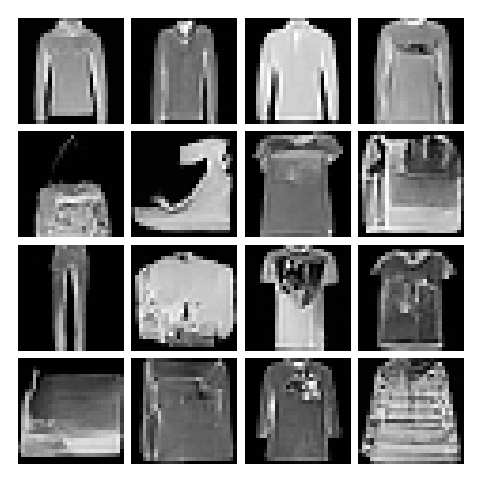

In [9]:
samples = sample(model, n_samples=16)
image = utils.make_grid(samples, nrow=4, pad_value=1.0)
plt.figure(figsize=(6, 6))
plt.imshow(image.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.show()

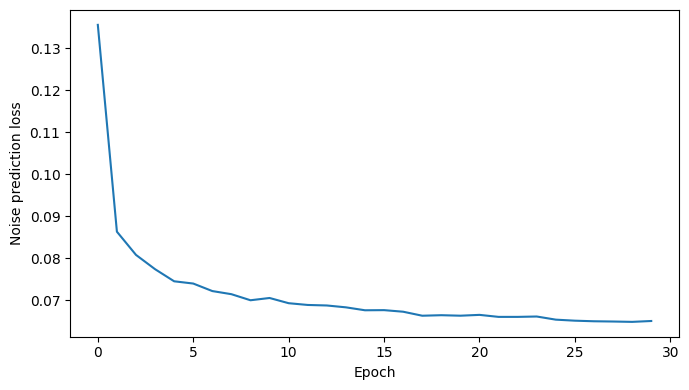

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Noise prediction loss")
plt.tight_layout()
plt.show()

## Quantitative Evaluation with FID and KID

Diffusion models are usually judged with the same distribution-level image metrics used for GANs and VAEs. In practice, one often reports FID and sometimes KID on a held-out reference set. The code below follows the same `torchmetrics` pattern used earlier, with one additional reminder: because our diffusion samples already return values in $[0,1]$, the preprocessing mainly consists of turning grayscale images into three channels.

In [11]:
def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_diffusion_fid_and_kid(model, real_loader, device, num_fake=1000, metric_batch_size=32):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    seen_real = 0
    real_target = num_fake
    for real_images, _ in tqdm(real_loader, desc="Diffusion real metrics", leave=False):
        remaining = real_target - seen_real
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = prepare_for_inception_metrics(0.5 * (real_images + 1.0))
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    generated = 0
    pbar = tqdm(total=num_fake, desc="diffusion fake metrics", leave=False)
    while generated < num_fake:
        batch_n = min(metric_batch_size, num_fake - generated)
        fake_images = sample(model, n_samples=batch_n, show_progress=False).to(device)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


metric_scores = compute_diffusion_fid_and_kid(model, train_loader, device)
print(metric_scores)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metrics:   0%|          | 0/469 [00:00<?, ?it/s]

diffusion fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 39.73265360082445, 'kid_mean': 0.019719481468200684, 'kid_std': 0.00242612068541348}


For diffusion, these scores often line up better with the visual experience than they do for tiny VAEs, because diffusion models tend to cover the data distribution more broadly while preserving decent sample quality. Even so, one should remain careful. A model can improve its FID while still sampling too slowly for a practical application, and no scalar metric captures the full tradeoff among quality, diversity, controllability, and compute.

## Practical Discussion

Even in this compact notebook, the most important ingredients of a modern diffusion model are already visible: a noise schedule, time conditioning, a U-Net style denoiser, the noise-prediction loss, and an iterative reverse sampler. Larger models refine each of these pieces rather than replacing them completely. They use stronger U-Nets, better schedules, more sophisticated parameterizations, and sometimes faster samplers such as DDIM or ODE-based methods, but the skeleton remains the same.

Pedagogically, this notebook is especially valuable because it closes the loop opened by the theory chapters. The discrete diffusion chapter explained why the noise-prediction objective arises from a variational decomposition. The continuous-time chapter explained why denoising, scores, and reverse stochastic dynamics are mathematically aligned. Here all of that becomes executable code.

When this notebook behaves reasonably well, one should expect the reverse samples to become progressively more recognizable as training proceeds, even if they remain far from the fidelity of modern large-scale systems. If the outputs remain pure noise, inspect whether the loss is decreasing and whether time conditioning is wired correctly. If outputs collapse to nearly identical shapes, the model capacity may be too small or the number of epochs too limited. If training is numerically unstable, the usual suspects are learning rate, normalization, or shape mismatches in the schedule broadcasting.

The broader lesson is that diffusion models are unusually clean examples of theory and implementation reinforcing each other. The theoretical derivation is not decorative; it tells us exactly what target to regress, why time conditioning is necessary, and why reverse sampling must be iterative. This makes the notebook especially valuable for a PhD course, where students should be able to map equations to code without hidden conceptual jumps.